**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade Aula 3.2

# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 17.43 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


In [6]:
print("Valores mínimo e máximo de Y:", torch.min(y_train), torch.max(y_train))

Valores mínimo e máximo de Y: tensor(0) tensor(9)


### Carregamento e normalização dos dados de validação

In [7]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

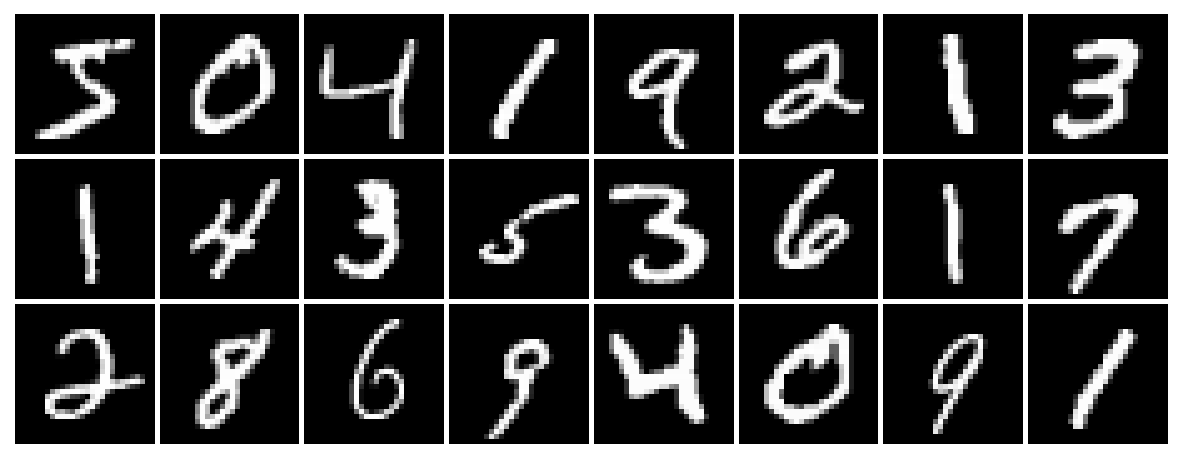

In [8]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


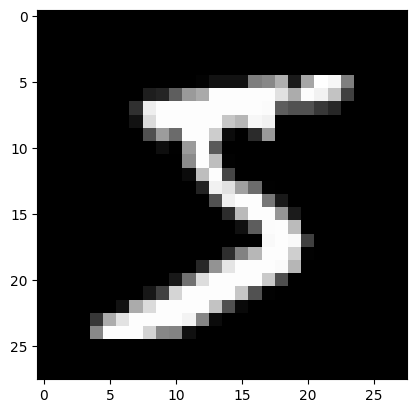

In [9]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

In [10]:
x_train[0].view(-1, 28*28).shape

torch.Size([1, 784])

In [11]:
x_train[0].view(-1, 28*28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

## Modelo

In [12]:
model = torch.nn.Linear(784, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [13]:
pred = model(x_train[:5].view(-1, 28*28))

In [15]:
xin = x_train[:5].view(-1,28*28)
score = model(xin)
score

tensor([[-0.2448,  0.3425,  0.0939,  0.0056, -0.2939,  0.1712, -0.2040,  0.1224,
          0.2352,  0.1955],
        [-0.0643,  0.3843,  0.0672, -0.0354, -0.5762,  0.0878,  0.0507, -0.1156,
          0.3528,  0.3343],
        [-0.1978,  0.1806,  0.0471,  0.2160, -0.2911, -0.1297, -0.0252,  0.0560,
          0.2328, -0.1623],
        [ 0.1855,  0.3240,  0.0512, -0.1256,  0.0127,  0.1133,  0.0142,  0.0105,
         -0.1468, -0.0105],
        [-0.0659,  0.2911,  0.0456,  0.0653, -0.1970,  0.1957, -0.0184, -0.2467,
         -0.0563, -0.0669]], grad_fn=<AddmmBackward0>)

In [16]:
import torch.nn.functional as F
prob = F.softmax(score, dim=1)
prob

tensor([[0.0735, 0.1322, 0.1031, 0.0944, 0.0700, 0.1114, 0.0765, 0.1061, 0.1187,
         0.1141],
        [0.0864, 0.1353, 0.0985, 0.0889, 0.0518, 0.1006, 0.0969, 0.0820, 0.1311,
         0.1287],
        [0.0814, 0.1189, 0.1040, 0.1231, 0.0742, 0.0872, 0.0968, 0.1049, 0.1252,
         0.0844],
        [0.1143, 0.1313, 0.0999, 0.0837, 0.0962, 0.1063, 0.0963, 0.0960, 0.0820,
         0.0940],
        [0.0930, 0.1329, 0.1039, 0.1060, 0.0816, 0.1208, 0.0975, 0.0776, 0.0939,
         0.0929]], grad_fn=<SoftmaxBackward0>)

In [17]:
torch.max(prob, 1)

torch.return_types.max(
values=tensor([0.1322, 0.1353, 0.1252, 0.1313, 0.1329], grad_fn=<MaxBackward0>),
indices=tensor([1, 1, 8, 1, 1]))

## Treinamento

### Inicialização dos parâmetros

In [18]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [19]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = x_train.view(-1, 28 * 28)
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, y_train)

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [20]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = x_train.view(-1, 28 * 28)
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, y_train)

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = x_val.view(-1, 28 * 28)
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, y_val)
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2646, Train Acc: 0.9420, Val Loss: 0.3963, Val Acc: 0.8950
Epoch [2/100], Train Loss: 0.2632, Train Acc: 0.9420, Val Loss: 0.3953, Val Acc: 0.8950
Epoch [3/100], Train Loss: 0.2619, Train Acc: 0.9420, Val Loss: 0.3944, Val Acc: 0.8950
Epoch [4/100], Train Loss: 0.2606, Train Acc: 0.9420, Val Loss: 0.3935, Val Acc: 0.8950
Epoch [5/100], Train Loss: 0.2594, Train Acc: 0.9420, Val Loss: 0.3926, Val Acc: 0.8950
Epoch [6/100], Train Loss: 0.2581, Train Acc: 0.9430, Val Loss: 0.3917, Val Acc: 0.8950
Epoch [7/100], Train Loss: 0.2569, Train Acc: 0.9430, Val Loss: 0.3908, Val Acc: 0.8950
Epoch [8/100], Train Loss: 0.2556, Train Acc: 0.9430, Val Loss: 0.3900, Val Acc: 0.8950
Epoch [9/100], Train Loss: 0.2544, Train Acc: 0.9450, Val Loss: 0.3891, Val Acc: 0.8950
Epoch [10/100], Train Loss: 0.2532, Train Acc: 0.9450, Val Loss: 0.3883, Val Acc: 0.8950
Epoch [11/100], Train Loss: 0.2520, Train Acc: 0.9460, Val Loss: 0.3875, Val Acc: 0.8950
Epoch [12/100], Train Loss: 0.

In [21]:
print('Final loss:', loss.item())

Final loss: 0.265889436006546


### Visualizando gráfico de perda durante o treinamento

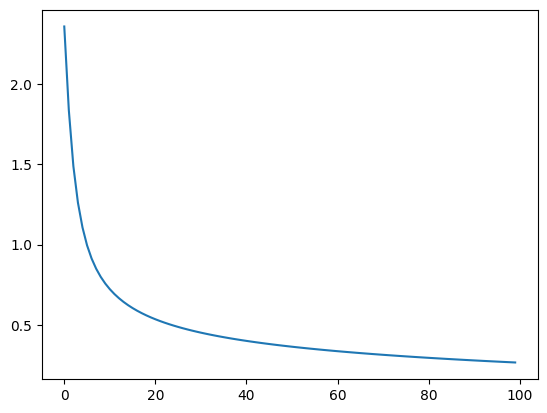

In [22]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

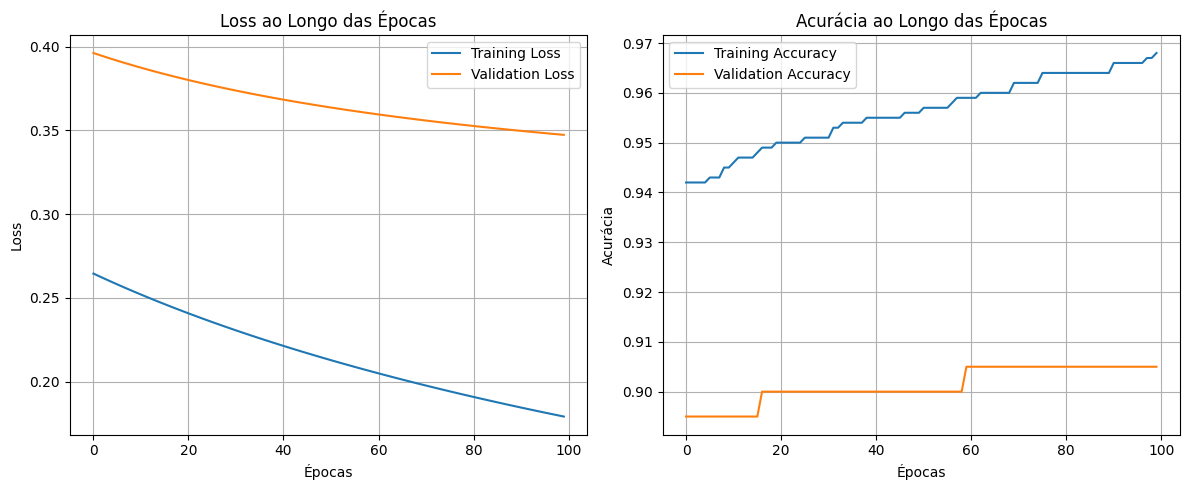

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [24]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.968


### Matriz de confusão com dados de treinamento e teste

In [25]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,0,0
2,0,0,93,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,103,1,0,1,0,2
5,0,1,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,2,1,0,0,0,0,0,86,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


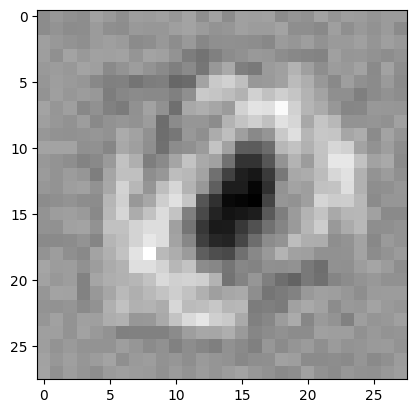

In [26]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[0, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

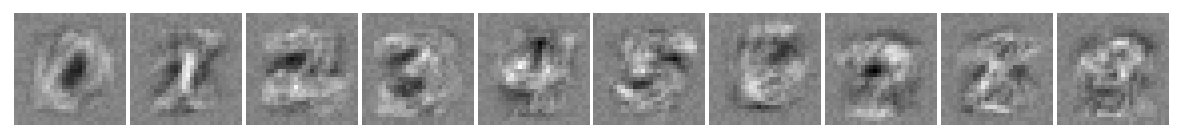

In [27]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

In [40]:
# Exercício 1: imprimir época, perda e acurácia no final de cada época
model_ex1 = torch.nn.Linear(784, 10)
criterion_ex1 = torch.nn.CrossEntropyLoss()
optimizer_ex1 = torch.optim.SGD(model_ex1.parameters(), lr=learningRate)

losses_ex1 = []
accs_ex1 = []

for epoch in range(epochs):
    inputs = x_train.view(-1, 28 * 28)
    outputs = model_ex1(inputs)
    loss = criterion_ex1(outputs, y_train)

    optimizer_ex1.zero_grad()
    loss.backward()
    optimizer_ex1.step()

    _, preds = torch.max(outputs, 1)
    acc = (preds == y_train).float().mean().item()

    losses_ex1.append(loss.item())
    accs_ex1.append(acc)

    print(f"Época [{epoch + 1}/{epochs}] - Loss: {loss.item():.6f} - Acc: {acc:.6f}")

Época [1/100] - Loss: 2.333805 - Acc: 0.058000
Época [2/100] - Loss: 1.816169 - Acc: 0.634000
Época [3/100] - Loss: 1.472786 - Acc: 0.767000
Época [4/100] - Loss: 1.250058 - Acc: 0.787000
Época [5/100] - Loss: 1.099064 - Acc: 0.812000
Época [6/100] - Loss: 0.991221 - Acc: 0.826000
Época [7/100] - Loss: 0.910549 - Acc: 0.838000
Época [8/100] - Loss: 0.847845 - Acc: 0.845000
Época [9/100] - Loss: 0.797527 - Acc: 0.853000
Época [10/100] - Loss: 0.756079 - Acc: 0.853000
Época [11/100] - Loss: 0.721201 - Acc: 0.854000
Época [12/100] - Loss: 0.691334 - Acc: 0.860000
Época [13/100] - Loss: 0.665386 - Acc: 0.861000
Época [14/100] - Loss: 0.642564 - Acc: 0.861000
Época [15/100] - Loss: 0.622280 - Acc: 0.868000
Época [16/100] - Loss: 0.604091 - Acc: 0.869000
Época [17/100] - Loss: 0.587651 - Acc: 0.873000
Época [18/100] - Loss: 0.572690 - Acc: 0.874000
Época [19/100] - Loss: 0.558993 - Acc: 0.876000
Época [20/100] - Loss: 0.546386 - Acc: 0.878000
Época [21/100] - Loss: 0.534725 - Acc: 0.878000
É

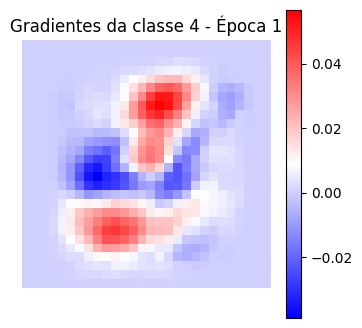

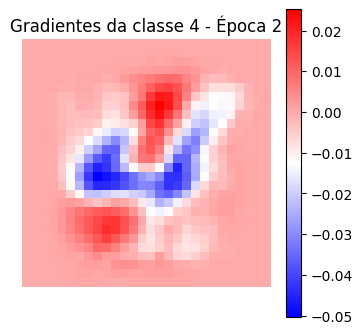

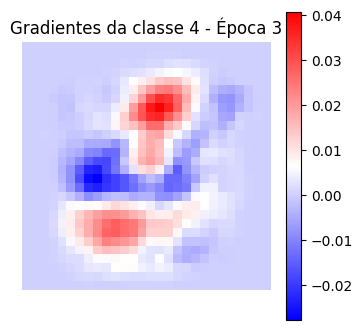

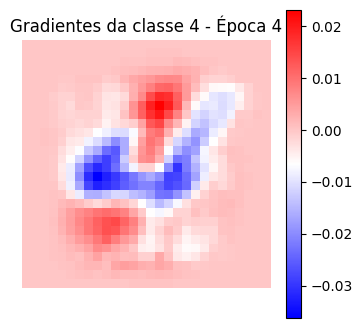

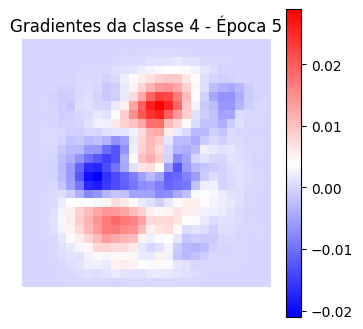

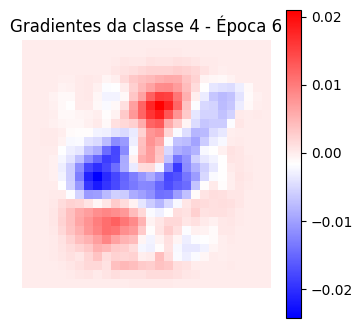

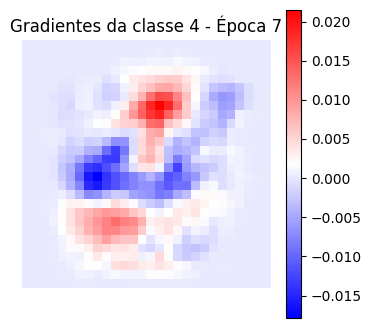

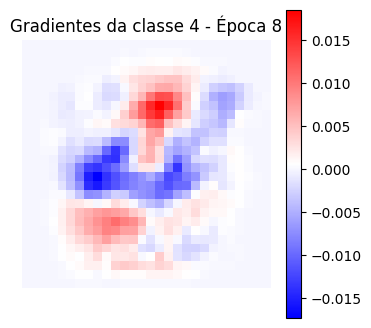

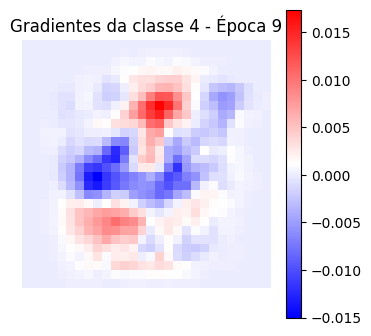

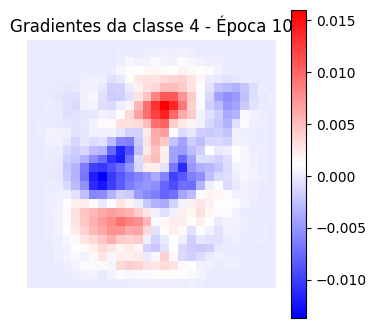

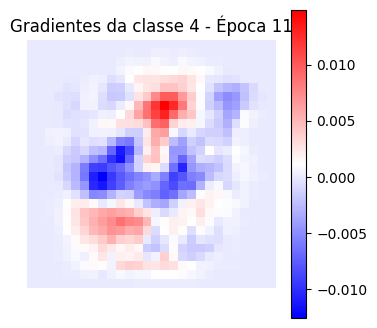

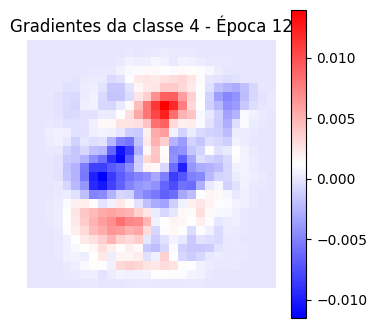

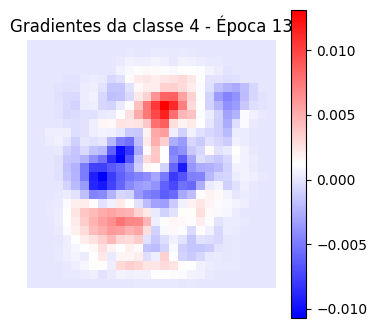

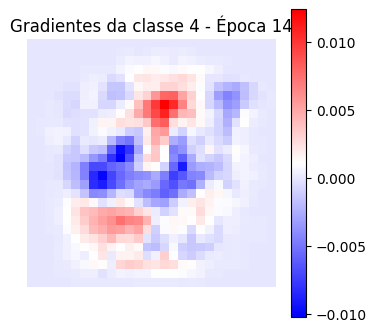

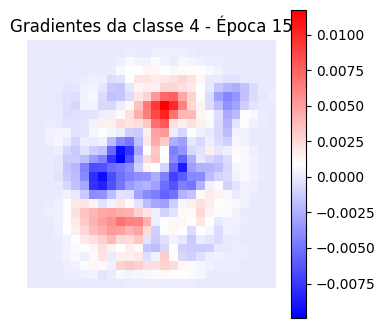

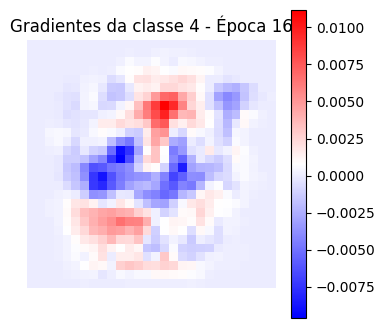

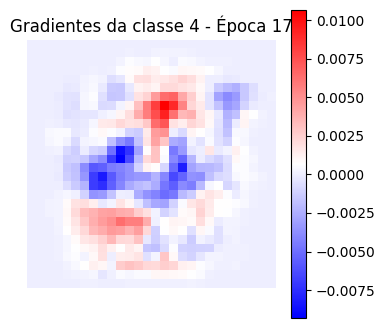

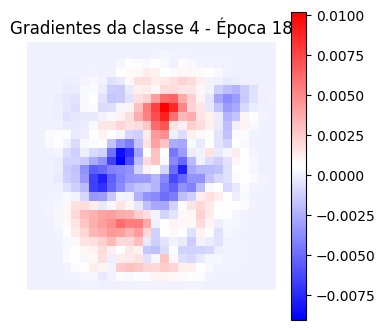

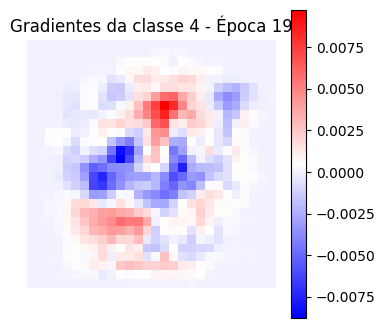

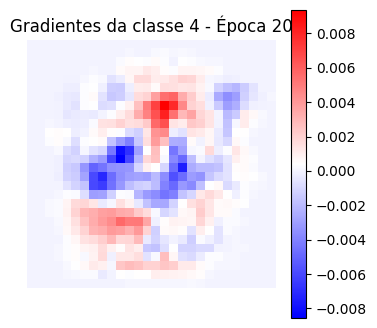

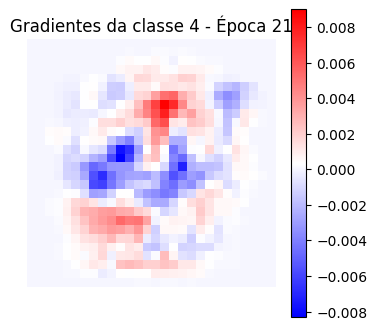

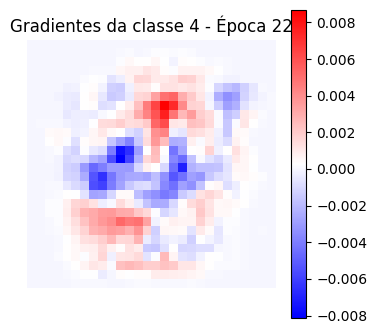

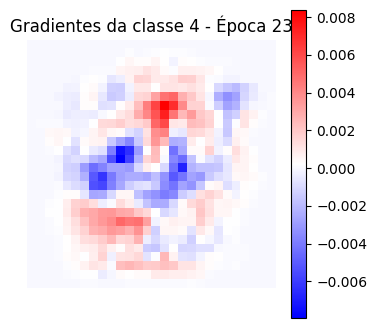

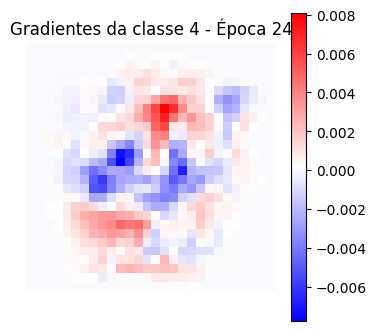

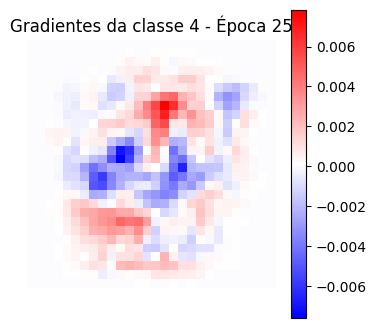

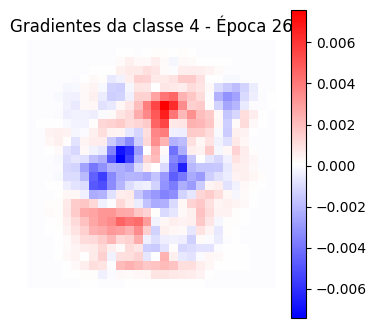

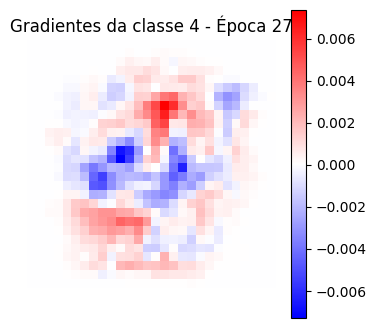

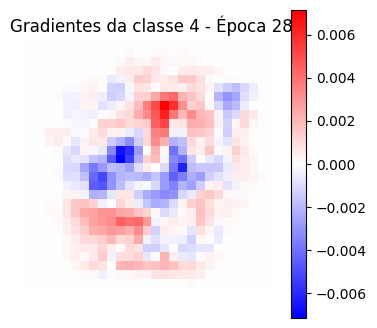

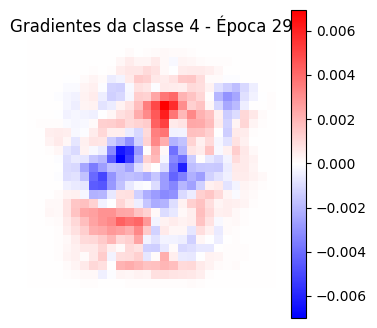

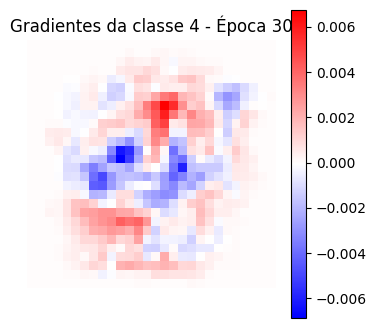

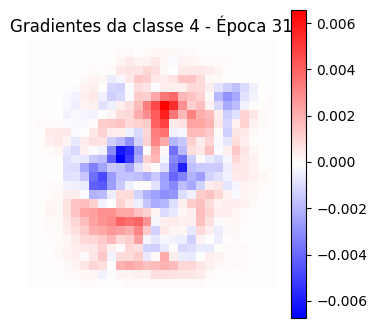

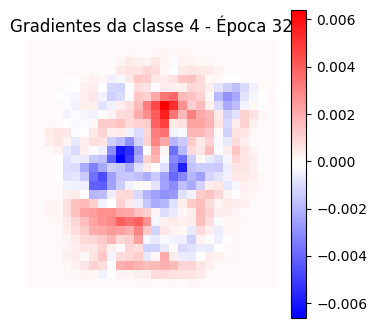

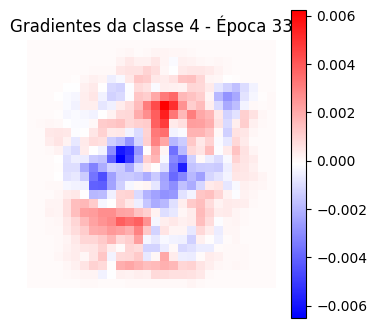

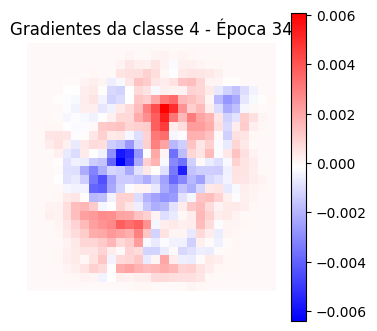

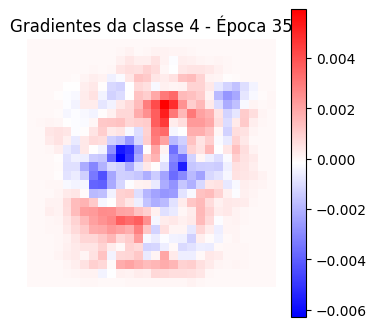

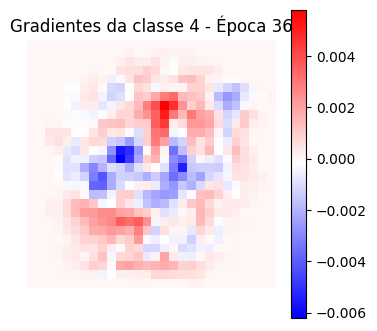

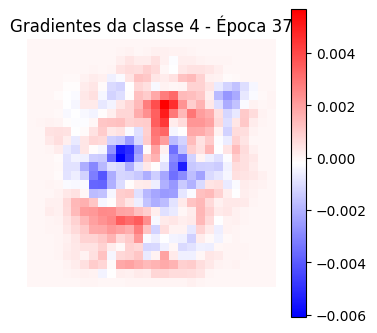

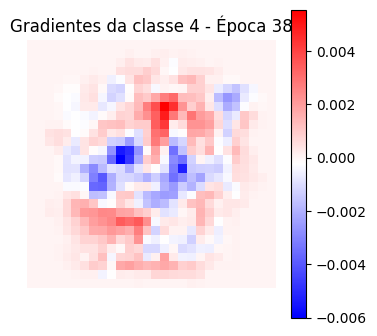

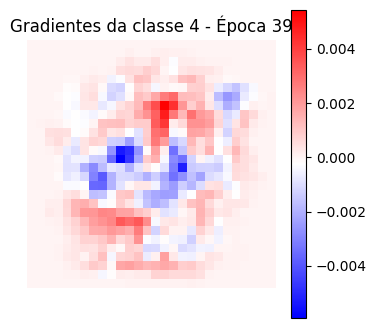

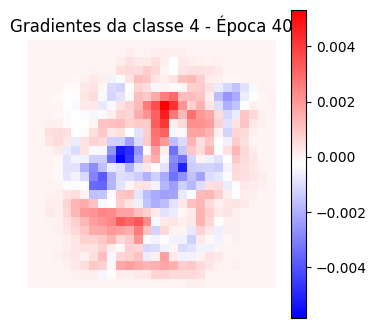

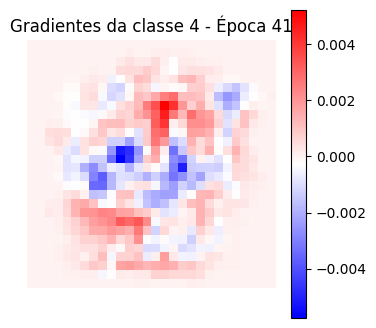

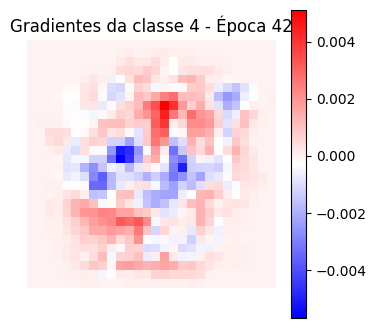

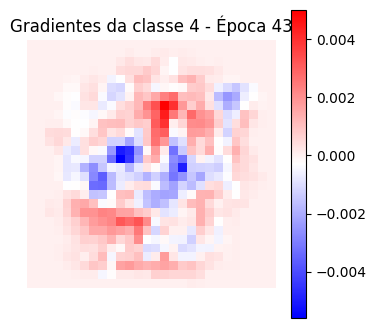

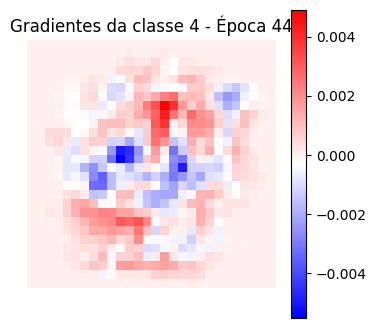

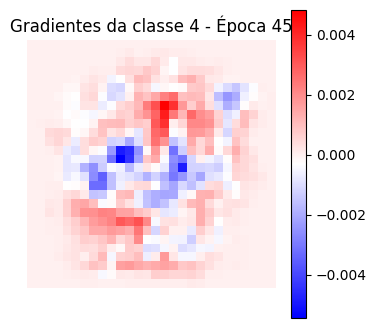

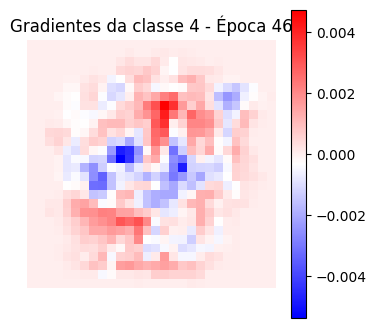

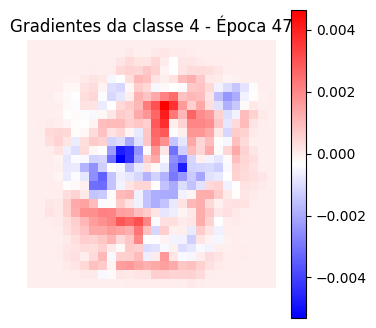

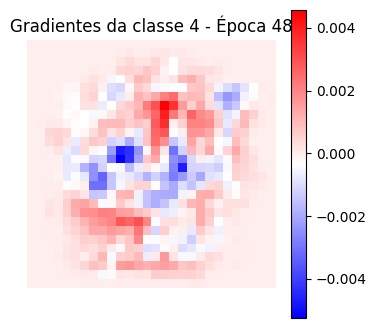

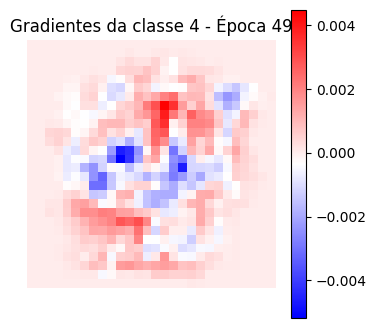

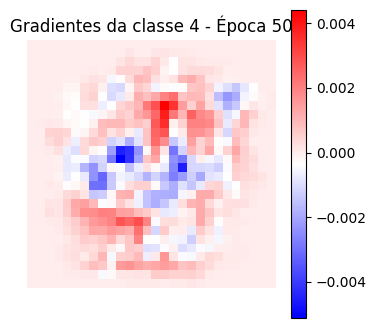

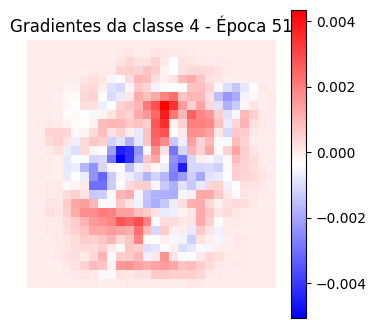

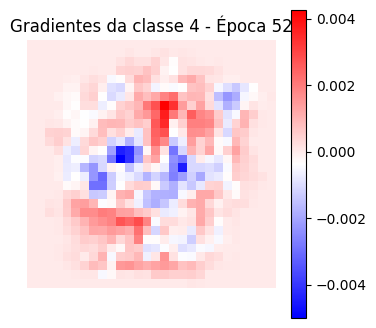

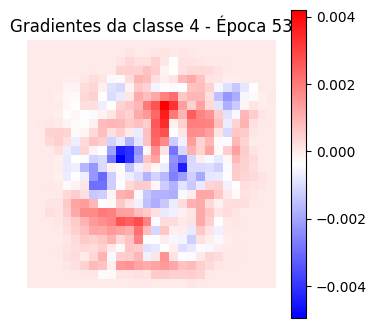

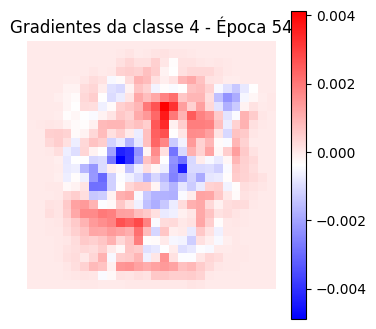

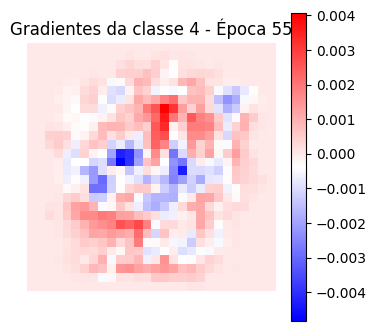

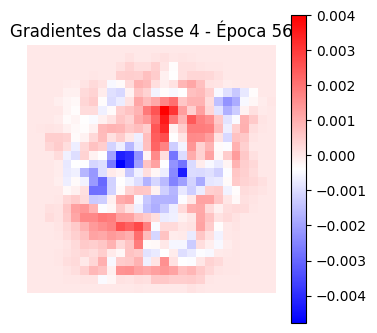

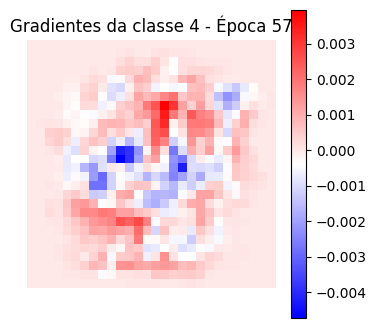

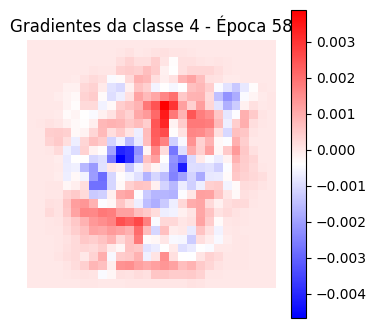

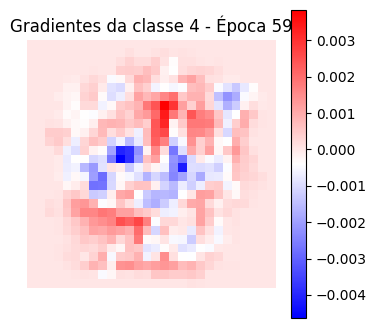

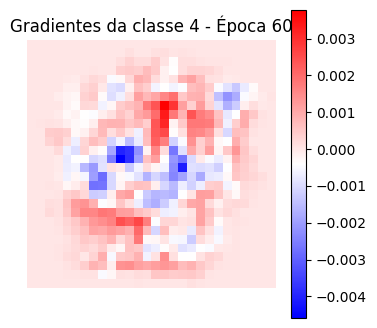

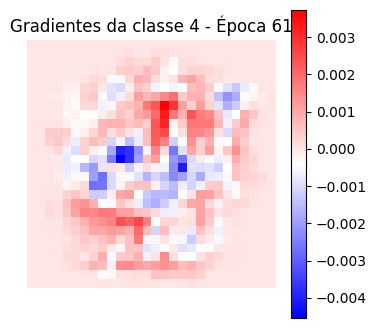

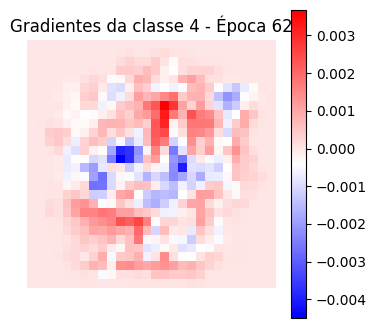

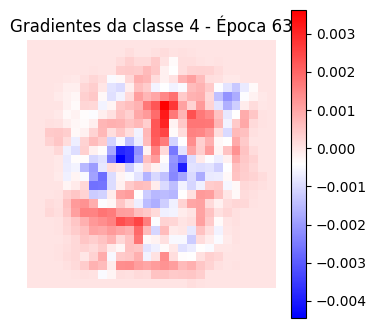

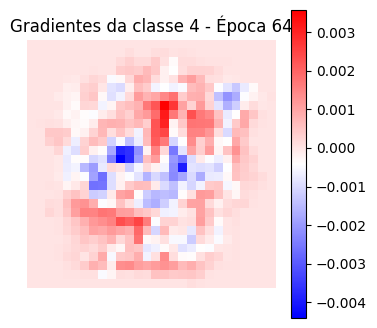

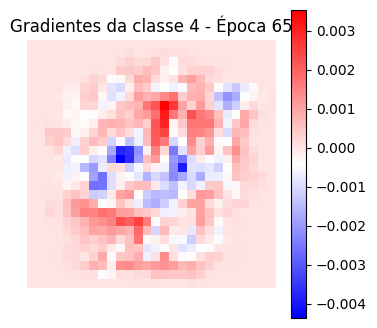

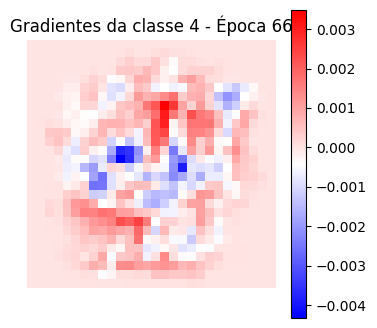

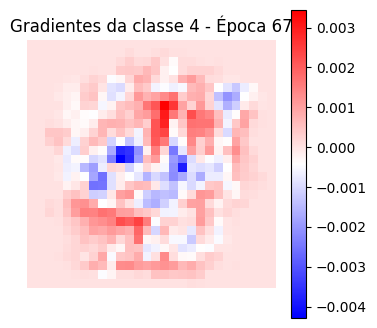

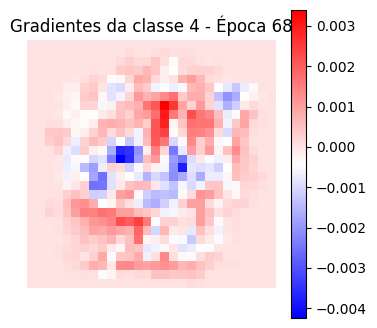

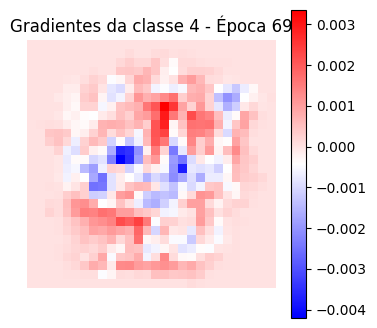

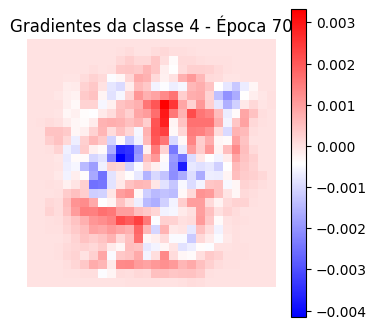

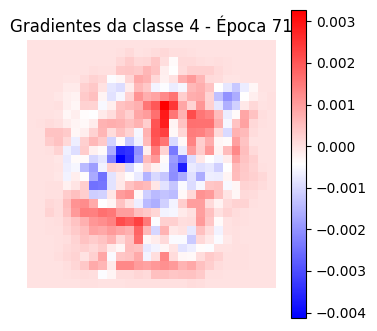

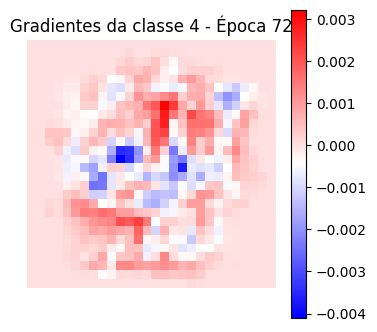

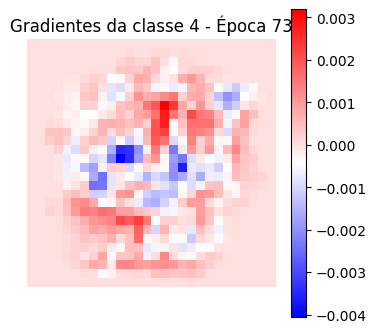

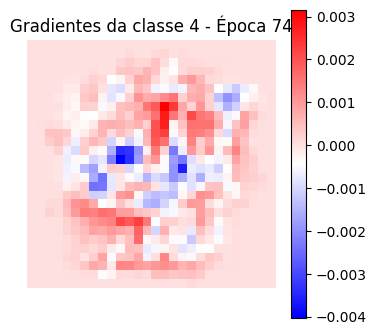

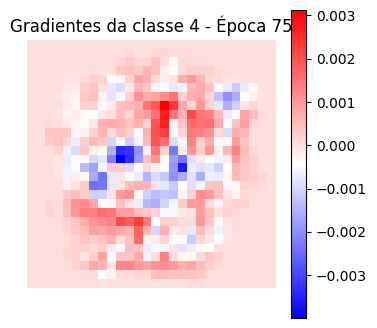

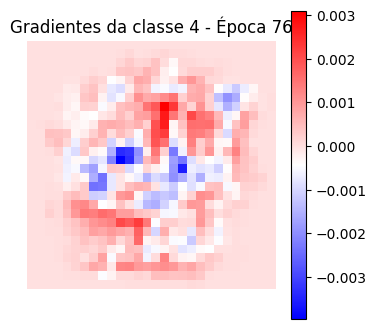

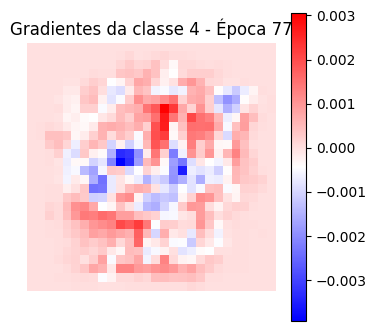

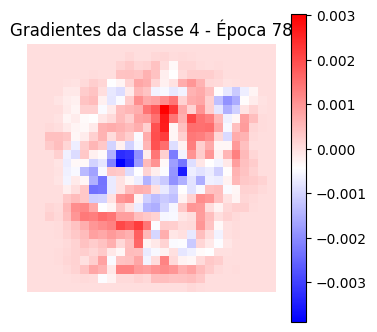

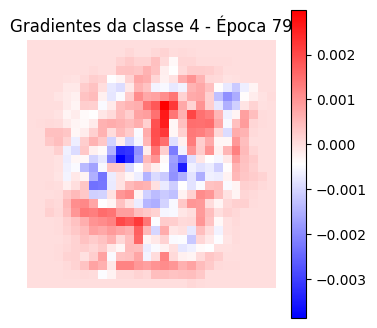

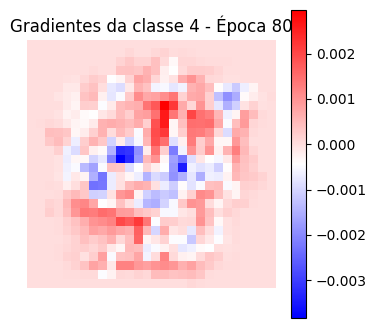

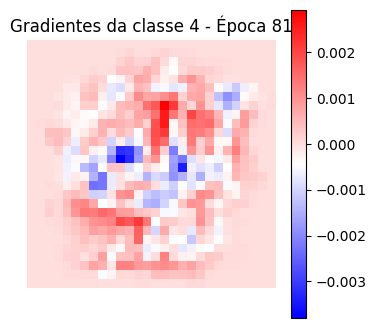

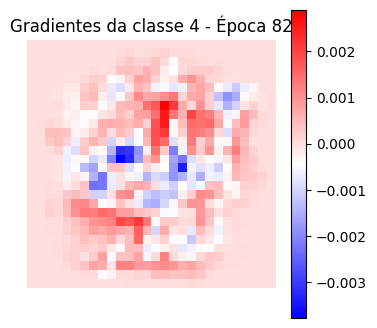

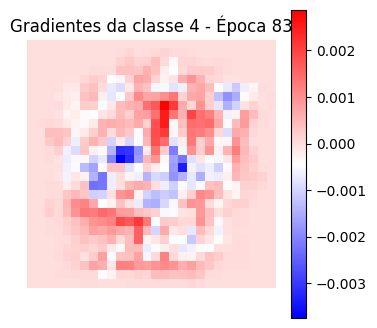

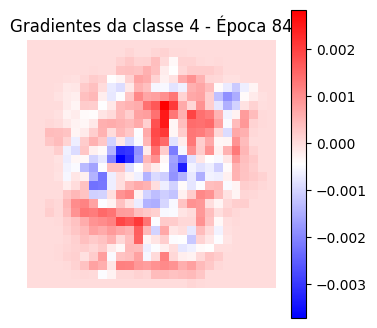

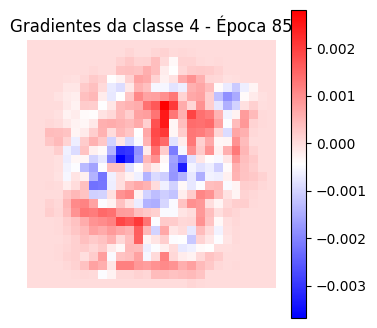

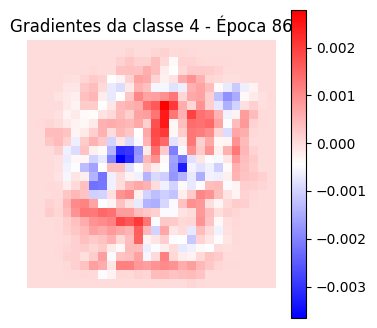

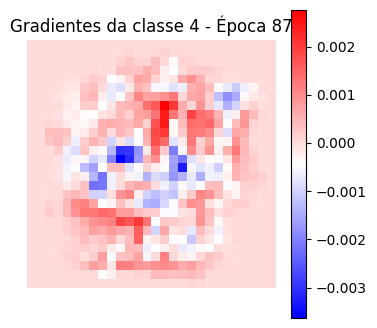

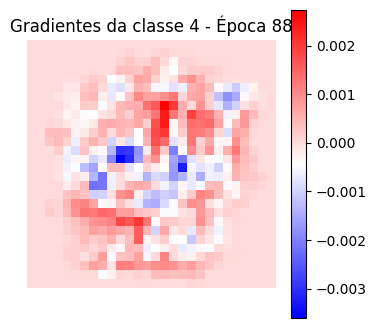

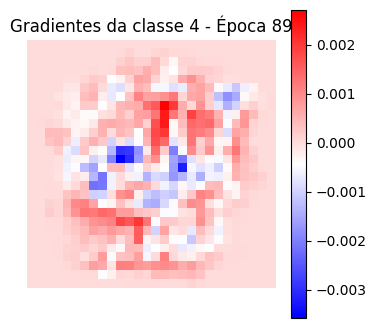

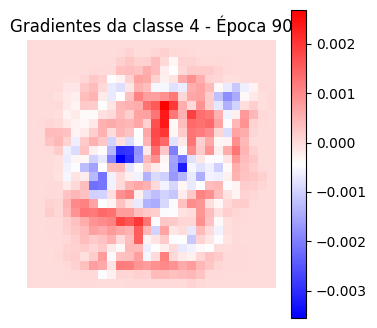

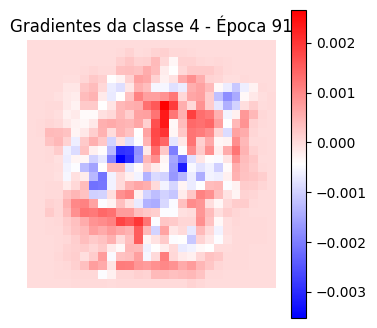

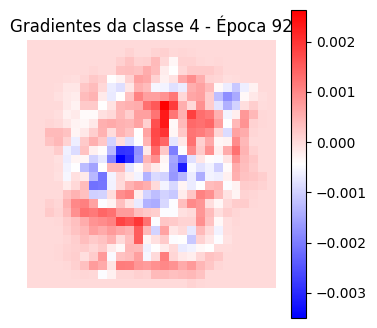

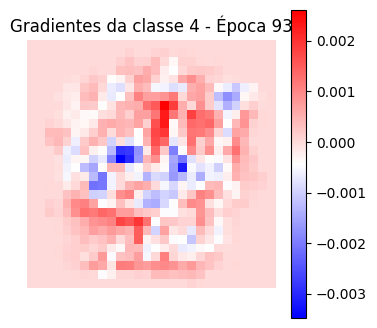

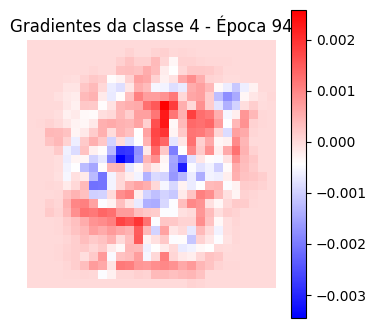

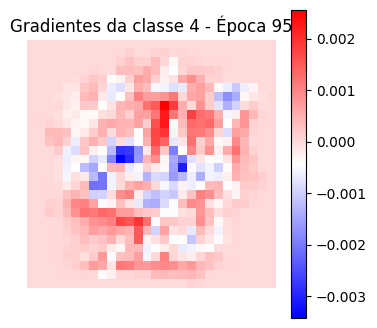

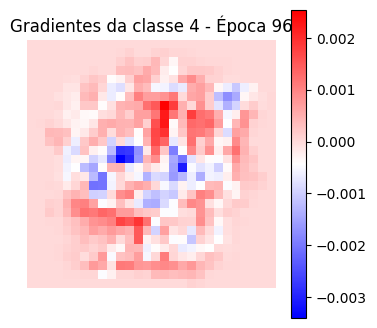

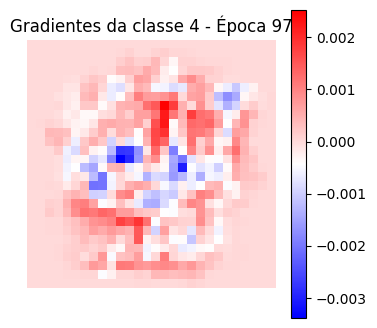

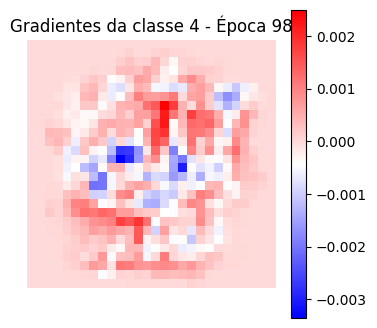

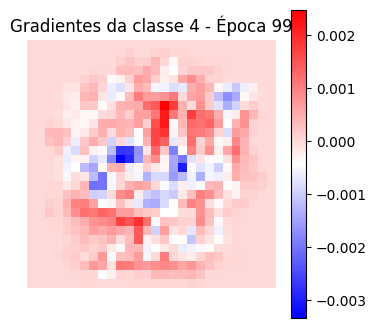

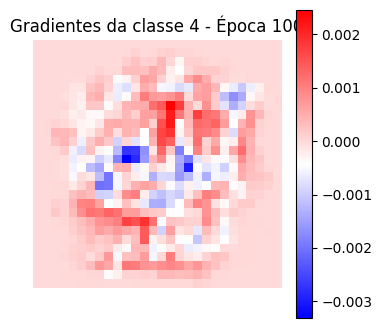

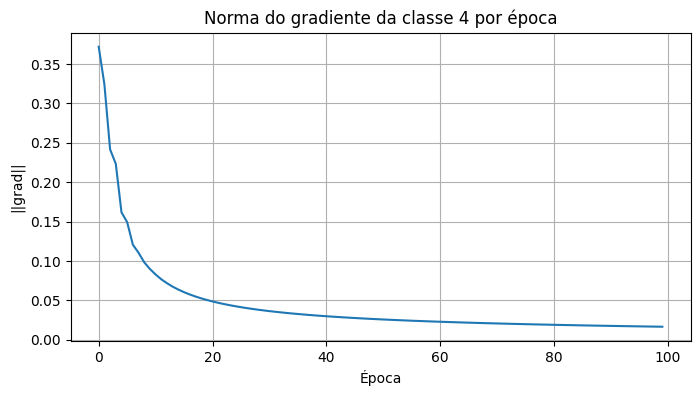

In [41]:
# Exercício 2: visualizar gradientes da classe do dígito 4 ao final de cada época
import matplotlib.pyplot as plt

model_ex2 = torch.nn.Linear(784, 10)
criterion_ex2 = torch.nn.CrossEntropyLoss()
optimizer_ex2 = torch.optim.SGD(model_ex2.parameters(), lr=learningRate)

grad_norms_class4 = []

for epoch in range(epochs):
    inputs = x_train.view(-1, 28 * 28)
    outputs = model_ex2(inputs)
    loss = criterion_ex2(outputs, y_train)

    optimizer_ex2.zero_grad()
    loss.backward()

    grad_class4 = model_ex2.weight.grad[4].detach().cpu().numpy()
    grad_norm_class4 = float(model_ex2.weight.grad[4].norm().item())
    grad_norms_class4.append(grad_norm_class4)

    optimizer_ex2.step()

    plt.figure(figsize=(4, 4))
    plt.imshow(grad_class4.reshape(28, 28), cmap='bwr')
    plt.title(f'Gradientes da classe 4 - Época {epoch + 1}')
    plt.colorbar()
    plt.axis('off')
    plt.show()

plt.figure(figsize=(8, 4))
plt.plot(grad_norms_class4)
plt.title('Norma do gradiente da classe 4 por época')
plt.xlabel('Época')
plt.ylabel('||grad||')
plt.grid(True)
plt.show()

## Perguntas

1. Qual é o shape da matriz de entrada na rede?

R.: [1, 784]

2. Qual é o shape da saída da rede?

R.: [1, 10]

3. Qual é o número total de parâmetros da rede, incluindo o bias?

R.: 7840 params + 10 (bias) = 7850 params

# Aprendizados
